# sEEG Full Processing Notebook

This notebook combines all validated features into one end-to-end workflow:
1. Load raw data from `test.npz`
2. Detect and remove bad channels
3. Apply notch + bandpass filtering and compute LMP
4. Build overlapping windows
5. Extract wavelet-based features (WPT and CWT)
6. Visualize features and CWT coefficient maps

## Step 0 - Imports and Function Definitions
Define all preprocessing, feature extraction, and visualization functions directly in this notebook so it runs without external imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
import pywt


def detect_bad_channels_stat(data, standard_range=(-500, 500)):
    """Detect bad sEEG channels using statistical features.

    Args:
        data: Array with shape (n_channels, n_samples).
        standard_range: Acceptable amplitude range in microvolts.
    """
    bad_channels_indices = []

    # 1) Detect constant/flat channels.
    constant_mask = np.all(np.isclose(data, data[:, [0]], atol=1e-5), axis=1)
    constant_channels = np.where(constant_mask)[0]
    bad_channels_indices.extend(constant_channels)

    # 2) Detect offset channels (DC shift/saturation).
    means = np.mean(data, axis=1)
    offset_mask = np.abs(means) > 20  # Threshold in microvolts.
    offset_channels = np.where(offset_mask)[0]
    bad_channels_indices.extend(offset_channels)

    # 3) Detect channels with samples outside the physiological range.
    outside_mask = np.any(
        (data < standard_range[0]) | (data > standard_range[1]),
        axis=1,
    )
    outside_channels = np.where(outside_mask)[0]
    bad_channels_indices.extend(outside_channels)

    # Deduplicate and sort channel indices.
    unique_bad_channels = sorted(set(bad_channels_indices))

    print(f"Constant channels: {constant_channels}")
    print(f"Offset channels: {offset_channels}")
    print(f"Outside standard range: {outside_channels}")

    return unique_bad_channels


def bandpass_filter(data, low_freq, high_freq, fs=2000, order=4):
    """Apply a band-pass filter to extract a target frequency band.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        low_freq: Low cutoff frequency in Hz.
        high_freq: High cutoff frequency in Hz.
        fs: Sampling rate in Hz (default: 2000).
        order: Filter order (default: 4).

    Returns:
        Filtered data with the same shape as input.
    """
    nyquist = fs / 2
    low = low_freq / nyquist
    high = high_freq / nyquist

    b, a = butter(order, [low, high], btype="band")
    filtered_data = filtfilt(b, a, data, axis=1)

    return filtered_data


def apply_notch_filter(data, freq=50, fs=2000, q=30):
    """Apply a notch filter to remove power-line interference.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        freq: Frequency to remove in Hz (50 or 60 typically).
        fs: Sampling rate in Hz.
        q: Quality factor; higher values produce a narrower notch.

    Returns:
        Filtered data with the same shape as input.
    """
    nyquist = fs / 2
    w0 = freq / nyquist

    b, a = iirnotch(w0, q)
    filtered_data = filtfilt(b, a, data, axis=1)

    return filtered_data


def create_windows(data, window_size, stride):
    """Create overlapping windows from channel-by-time data.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        window_size: Window length in samples.
        stride: Step between consecutive windows in samples.

    Returns:
        3D array with shape (n_windows, n_channels, window_size).
    """
    _, n_samples = data.shape
    windows = []
    for i in range(0, n_samples - window_size + 1, stride):
        windows.append(data[:, i : i + window_size])
    return np.array(windows)


def calculate_lmp(data, window_ms=250, fs=2000):
    """Calculate Local Motor Potential (LMP) as a running average.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        window_ms: Window size for running average in milliseconds.
        fs: Sampling rate in Hz.

    Returns:
        LMP data with the same shape as input.
    """
    window_size = int(window_ms * fs / 1000)
    window = np.ones(window_size) / window_size
    lmp_data = np.apply_along_axis(
        lambda x: np.convolve(x, window, mode="same"),
        axis=1,
        arr=data,
    )
    return lmp_data


def filter_seeg_data(data, fs=2000):
    """Run the full sEEG filtering pipeline.

    Steps:
        1) Apply notch filtering to remove power-line noise.
        2) Apply band-pass filtering to obtain low/high frequency bands.
        3) Calculate Local Motor Potential (LMP) as running average.
    """
    data_no_notch = apply_notch_filter(data, freq=50, fs=fs)
    lfb_result = bandpass_filter(data_no_notch, 0.5, 30, fs)
    hfb_result = bandpass_filter(data_no_notch, 80, 200, fs)
    lmp_result = calculate_lmp(data_no_notch, window_ms=250, fs=fs)
    return lfb_result, hfb_result, lmp_result


def extract_wpt_features(data, wavelet="db4", level=4):
    """Extract features using Wavelet Packet Transform (WPT).

    Args:
        data: 2D array with shape (n_channels, n_samples).
        wavelet: Wavelet family to use.
        level: Decomposition level.

    Returns:
        2D array of normalized energies per node, shape (n_channels, 2**level).
    """
    n_channels, _ = data.shape
    features = []

    for channel in range(n_channels):
        wp = pywt.WaveletPacket(
            data[channel], wavelet=wavelet, mode="symmetric", maxlevel=level
        )
        nodes = wp.get_level(level, "natural")

        channel_features = []
        for node in nodes:
            energy = np.sum(np.square(node.data))
            channel_features.append(energy)

        total_energy = np.sum(channel_features)
        if total_energy > 0:
            channel_features = np.array(channel_features) / total_energy
        else:
            channel_features = np.zeros(len(channel_features))

        features.append(channel_features)

    return np.array(features)


def extract_cwt_features(data, wavelet="morl", scales=np.arange(1, 128)):
    """Extract features using Continuous Wavelet Transform (CWT).

    Args:
        data: 2D array with shape (n_channels, n_samples).
        wavelet: Wavelet family to use.
        scales: Scales to use for CWT.

    Returns:
        2D array with shape (n_channels, 3 * len(scales)) containing
        mean abs value, std, and energy for each scale.
    """
    n_channels, _ = data.shape
    features = []

    for channel in range(n_channels):
        coeffs, _ = pywt.cwt(data[channel], scales, wavelet)

        channel_features = []
        for i in range(len(scales)):
            mean_abs = np.mean(np.abs(coeffs[i]))
            std = np.std(coeffs[i])
            energy = np.sum(np.square(coeffs[i]))
            channel_features.extend([mean_abs, std, energy])

        features.append(channel_features)

    return np.array(features)


def visualize_wpt_features(wpt_features, level=4, step=50):
    """Visualize WPT feature energies for each channel (every `step`-th channel)."""
    _ = level
    wpt_features = wpt_features[::step]
    n_channels = wpt_features.shape[0]
    n_features = wpt_features.shape[1]

    _, axes = plt.subplots(n_channels, 1, figsize=(10, 2 * n_channels))
    if n_channels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        band_labels = [f"Band {j + 1}" for j in range(n_features)]
        ax.bar(band_labels, wpt_features[i])
        ax.set_title(f"WPT Features - Channel {i * step + 1}")
        ax.set_xlabel("Frequency Band")
        ax.set_ylabel("Normalized Energy")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def visualize_cwt_features(cwt_features, scales=np.arange(1, 32), step=50):
    """Visualize CWT summary features for each channel and scale (every `step`-th channel)."""
    cwt_features = cwt_features[::step]
    n_channels = cwt_features.shape[0]
    n_scales = len(scales)

    _, axes = plt.subplots(n_channels, 3, figsize=(15, 2 * n_channels))
    if n_channels == 1:
        axes = [axes]

    feature_names = ["Mean Absolute Value", "Standard Deviation", "Energy"]

    for i, ax_row in enumerate(axes):
        for j, ax in enumerate(ax_row):
            start_idx = j * n_scales
            end_idx = (j + 1) * n_scales
            features = cwt_features[i, start_idx:end_idx]

            ax.plot(scales, features)
            ax.set_title(f"{feature_names[j]} - Channel {i * step + 1}")
            ax.set_xlabel("Scale")
            ax.set_ylabel(feature_names[j])
            ax.grid(True)

    plt.tight_layout()
    plt.show()


def visualize_cwt_coeffs(data, channel=0, wavelet="morl", scales=np.arange(1, 32)):
    """Visualize CWT coefficients and the original signal for one channel."""
    import matplotlib.colors as colors

    coeffs, _ = pywt.cwt(data[channel], scales, wavelet)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [1, 3]}
    )

    ax1.plot(data[channel])
    ax1.set_title(f"Original Signal - Channel {channel + 1}")
    ax1.set_xlabel("Sample")
    ax1.set_ylabel("Amplitude")

    im = ax2.imshow(coeffs, aspect="auto", cmap="jet", norm=colors.LogNorm())
    ax2.set_title(f"CWT Coefficients - Channel {channel + 1}")
    ax2.set_xlabel("Sample")
    ax2.set_ylabel("Scale")

    cbar = fig.colorbar(im, ax=ax2)
    cbar.set_label("Coefficient Magnitude")

    plt.tight_layout()
    plt.show()


def compute_covariance_matrices(windows, labels):
    """Compute normalized covariance matrices for each class.

    Args:
        windows: 3D array (n_windows, n_channels, n_samples).
        labels: 1D array of class labels (0 or 1).

    Returns:
        Tuple of (cov_class0, cov_class1) covariance matrices.
    """
    classes = np.unique(labels)
    cov_matrices = []
    for c in classes:
        class_windows = windows[labels == c]
        cov_sum = np.zeros((class_windows.shape[1], class_windows.shape[1]))
        for w in class_windows:
            cov_sum += np.dot(w, w.T)
        cov_matrices.append(cov_sum / np.trace(cov_sum))
    return cov_matrices[0], cov_matrices[1]


def compute_csp_filters(cov0, cov1, n_components=4):
    """Compute CSP spatial filters from two covariance matrices.

    Args:
        cov0: Covariance matrix for class 0.
        cov1: Covariance matrix for class 1.
        n_components: Number of filter pairs to return (default 4).

    Returns:
        Spatial filter matrix (n_components, n_channels).
    """
    cov_sum = cov0 + cov1
    eigvals, eigvecs = np.linalg.eigh(cov_sum)
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]

    whitening_matrix = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
    cov0_white = whitening_matrix @ cov0 @ whitening_matrix.T

    eigvals_white, eigvecs_white = np.linalg.eigh(cov0_white)
    eigvals_white = eigvals_white[::-1]
    eigvecs_white = eigvecs_white[:, ::-1]

    csp_filters = eigvecs_white.T @ whitening_matrix

    first_last = []
    half = n_components // 2
    for i in range(half):
        first_last.append(i)
    for i in range(-half, 0):
        first_last.append(i)

    return csp_filters[first_last]


def apply_csp(windows, csp_filters):
    """Apply CSP filters and return log-variance features.

    Args:
        windows: 3D array (n_windows, n_channels, n_samples).
        csp_filters: Spatial filter matrix (n_components, n_channels).

    Returns:
        Log-variance features (n_windows, n_components).
    """
    projected = np.einsum("fc,wcs->wfs", csp_filters, windows)
    variances = np.var(projected, axis=2)
    log_var = np.log(variances)
    return log_var


def extract_fbcsp_features(hfb_windows, lmp_windows, labels, n_components=4):
    """Extract Filter Bank CSP features from multiple frequency bands.

    Args:
        hfb_windows: HFB windowed data (n_windows, n_channels, n_samples).
        lmp_windows: LMP windowed data (n_windows, n_channels, n_samples).
        labels: Class labels (n_windows,).
        n_components: Number of CSP filter pairs per band.

    Returns:
        Dictionary with 'features', 'filters', and 'band_names'.
    """
    bands = {"HFB": hfb_windows, "LMP": lmp_windows}
    all_features = []
    all_filters = {}
    band_names = []

    for band_name, band_windows in bands.items():
        cov0, cov1 = compute_covariance_matrices(band_windows, labels)
        filters = compute_csp_filters(cov0, cov1, n_components=n_components)
        features = apply_csp(band_windows, filters)
        all_features.append(features)
        all_filters[band_name] = filters
        band_names.append(band_name)

    combined_features = np.hstack(all_features)
    return {
        "features": combined_features,
        "filters": all_filters,
        "band_names": band_names,
    }


def visualize_csp_filters(csp_filters, band_name="", step=50):
    """Visualize CSP spatial patterns as channel weight bar plots.

    Args:
        csp_filters: Filter matrix (n_components, n_channels).
        band_name: Name of the frequency band.
        step: Only show every `step`-th channel.
    """
    n_components = csp_filters.shape[0]
    n_channels = csp_filters.shape[1]

    fig, axes = plt.subplots(1, n_components, figsize=(4 * n_components, 4))
    if n_components == 1:
        axes = [axes]

    channel_indices = np.arange(0, n_channels, step)
    for i, ax in enumerate(axes):
        weights = csp_filters[i, channel_indices]
        colors_bar = ["red" if w < 0 else "blue" for w in weights]
        ax.bar(range(len(channel_indices)), weights, color=colors_bar)
        ax.set_title(f"Filter {i + 1} ({band_name})")
        ax.set_xlabel(f"Channel (every {step}-th)")
        ax.set_ylabel("Weight")
        ax.axhline(y=0, color="black", linewidth=0.5)

    plt.tight_layout()
    plt.show()


def visualize_csp_features(features, labels, band_names):
    """Visualize CSP log-variance features separated by class.

    Args:
        features: CSP features (n_windows, n_components_total).
        labels: Class labels (n_windows,).
        band_names: List of band names used.
    """
    n_components = features.shape[1]
    n_cols = min(n_components, 4)
    n_rows = int(np.ceil(n_components / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
    if n_components == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    classes = np.unique(labels)
    for i in range(n_components):
        ax = axes[i]
        for c in classes:
            ax.hist(features[labels == c, i], bins=15, alpha=0.5, label=f"Class {c}")
        band_idx = i // (n_components // len(band_names)) if len(band_names) > 1 else 0
        ax.set_title(f"CSP Feature {i + 1} ({band_names[band_idx] if band_idx < len(band_names) else ''})")
        ax.set_xlabel("Log-Variance")
        ax.set_ylabel("Count")
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (12, 4)

## Step 1 - Load Raw sEEG Data
Load the `.npz` file and convert data to shape `(channels, samples)`.

In [2]:
npzfile = np.load('test.npz')
key = npzfile.files[0]
data_raw = npzfile[key]

# Ensure shape is (channels, samples).
if data_raw.shape[0] > data_raw.shape[1]:
    data_raw = data_raw.T

print(f'Data key: {key}')
print(f'Raw data shape (channels, samples): {data_raw.shape}')
print(f'Dtype: {data_raw.dtype}')

Data key: arr_0
Raw data shape (channels, samples): (276, 6200)
Dtype: float32


## Step 2 - Detect and Remove Bad Channels
Use statistical checks to identify flat, offset, and out-of-range channels, then keep only good channels.

In [3]:
bad_indices = detect_bad_channels_stat(data_raw)

keep_mask = np.ones(data_raw.shape[0], dtype=bool)
keep_mask[bad_indices] = False
data_clean = data_raw[keep_mask]

print(f'Bad channels: {bad_indices}')
print(f'Original shape: {data_raw.shape}')
print(f'Cleaned shape: {data_clean.shape}')
print(f'Removed channels: {len(bad_indices)}')

Constant channels: [272 273 274 275]
Offset channels: [  0   2   3   4  10  14  21  24  29  30  35  37  48  57  71  82  83  92
  93  98 105 107 119 123 256 257 258 259 260 261 262 263 264 265 266 267
 268 269 270 271 272 273 274]
Outside standard range: [126 127 273 274]
Bad channels: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(10), np.int64(14), np.int64(21), np.int64(24), np.int64(29), np.int64(30), np.int64(35), np.int64(37), np.int64(48), np.int64(57), np.int64(71), np.int64(82), np.int64(83), np.int64(92), np.int64(93), np.int64(98), np.int64(105), np.int64(107), np.int64(119), np.int64(123), np.int64(126), np.int64(127), np.int64(256), np.int64(257), np.int64(258), np.int64(259), np.int64(260), np.int64(261), np.int64(262), np.int64(263), np.int64(264), np.int64(265), np.int64(266), np.int64(267), np.int64(268), np.int64(269), np.int64(270), np.int64(271), np.int64(272), np.int64(273), np.int64(274), np.int64(275)]
Original shape: (276, 6200)
Cleaned shape: (230

c:\Users\hilin\miniconda3\envs\data_env\lib\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


## Step 3 - Filter the Signals and Compute LMP
Run the full preprocessing pipeline:
- Notch filter (50 Hz)
- LFB band (0.5-30 Hz)
- HFB band (80-200 Hz)
- LMP running average

LFB shape: (230, 6200)
HFB shape: (230, 6200)
LMP shape: (230, 6200)


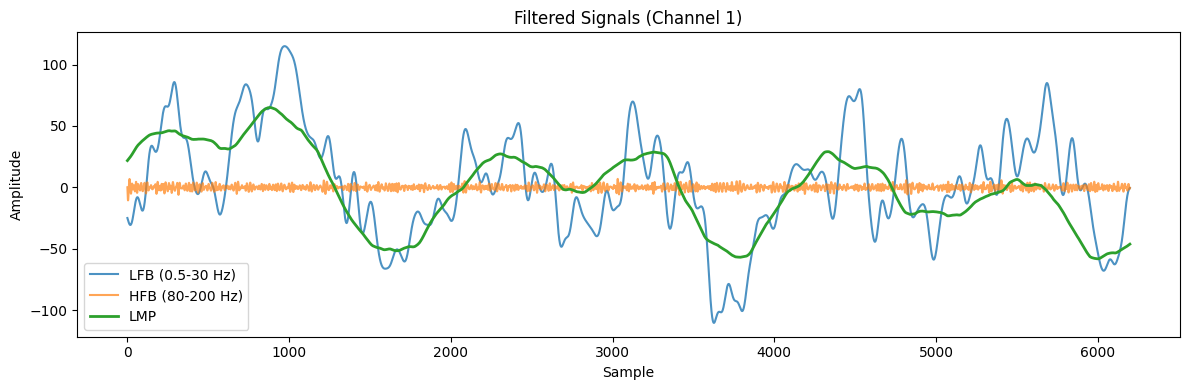

In [4]:
fs = 2000
lfb_data, hfb_data, lmp_data = filter_seeg_data(data_clean, fs=fs)

print(f'LFB shape: {lfb_data.shape}')
print(f'HFB shape: {hfb_data.shape}')
print(f'LMP shape: {lmp_data.shape}')

ch = 0
plt.figure()
plt.plot(lfb_data[ch], label='LFB (0.5-30 Hz)', alpha=0.8)
plt.plot(hfb_data[ch], label='HFB (80-200 Hz)', alpha=0.7)
plt.plot(lmp_data[ch], label='LMP', linewidth=2)
plt.title(f'Filtered Signals (Channel {ch + 1})')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

## Step 4 - Create Overlapping Windows
Create sliding windows for downstream feature extraction.

In [5]:
window_size = 250
stride = 225

hfb_windows = create_windows(hfb_data, window_size=window_size, stride=stride)
lmp_windows = create_windows(lmp_data, window_size=window_size, stride=stride)

print(f'HFB windows shape: {hfb_windows.shape}')
print(f'LMP windows shape: {lmp_windows.shape}')

HFB windows shape: (27, 230, 250)
LMP windows shape: (27, 230, 250)


## Step 5 - Extract Wavelet Features
Extract two complementary wavelet representations from HFB data:
- **WPT**: normalized energy per decomposition band
- **CWT**: mean absolute value, standard deviation, and energy per scale

In [6]:
wpt_features = extract_wpt_features(hfb_data, wavelet='db4', level=4)
scales = np.arange(1, 32)
cwt_features = extract_cwt_features(hfb_data, wavelet='morl', scales=scales)

print(f'WPT features shape: {wpt_features.shape}')
print(f'CWT features shape: {cwt_features.shape}')
print('WPT first channel (first 8 values):', wpt_features[0][:8])
print('CWT first channel (first 9 values):', cwt_features[0][:9])

WPT features shape: (230, 16)
CWT features shape: (230, 93)
WPT first channel (first 8 values): [0.148  0.4725 0.0294 0.3267 0.0011 0.0034 0.0066 0.0119]
CWT first channel (first 9 values): [ 0.0618  0.0785 38.218   0.0009  0.0089  0.4954  0.0081  0.0224  3.1117]


## Step 6 - Visualize Wavelet Results
Plot:
1. WPT normalized energies
2. CWT summary feature curves
3. CWT coefficient map for a selected channel

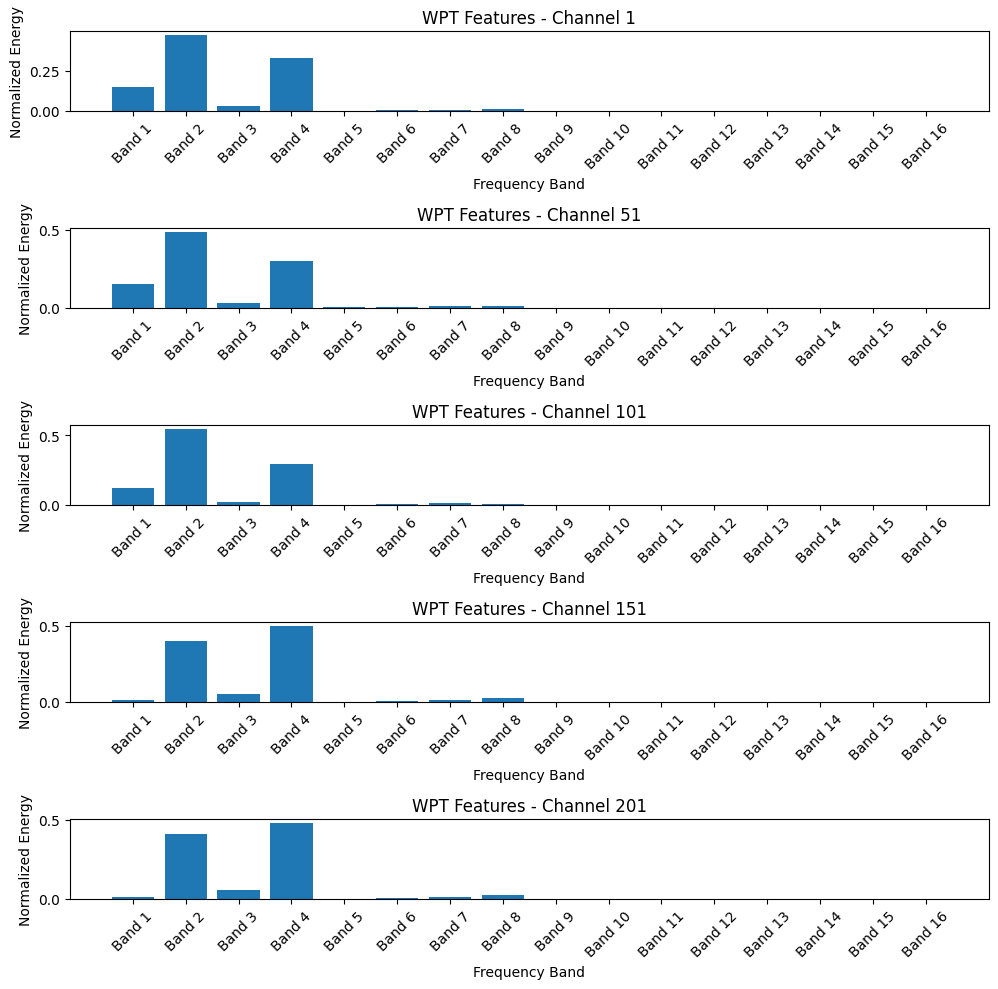

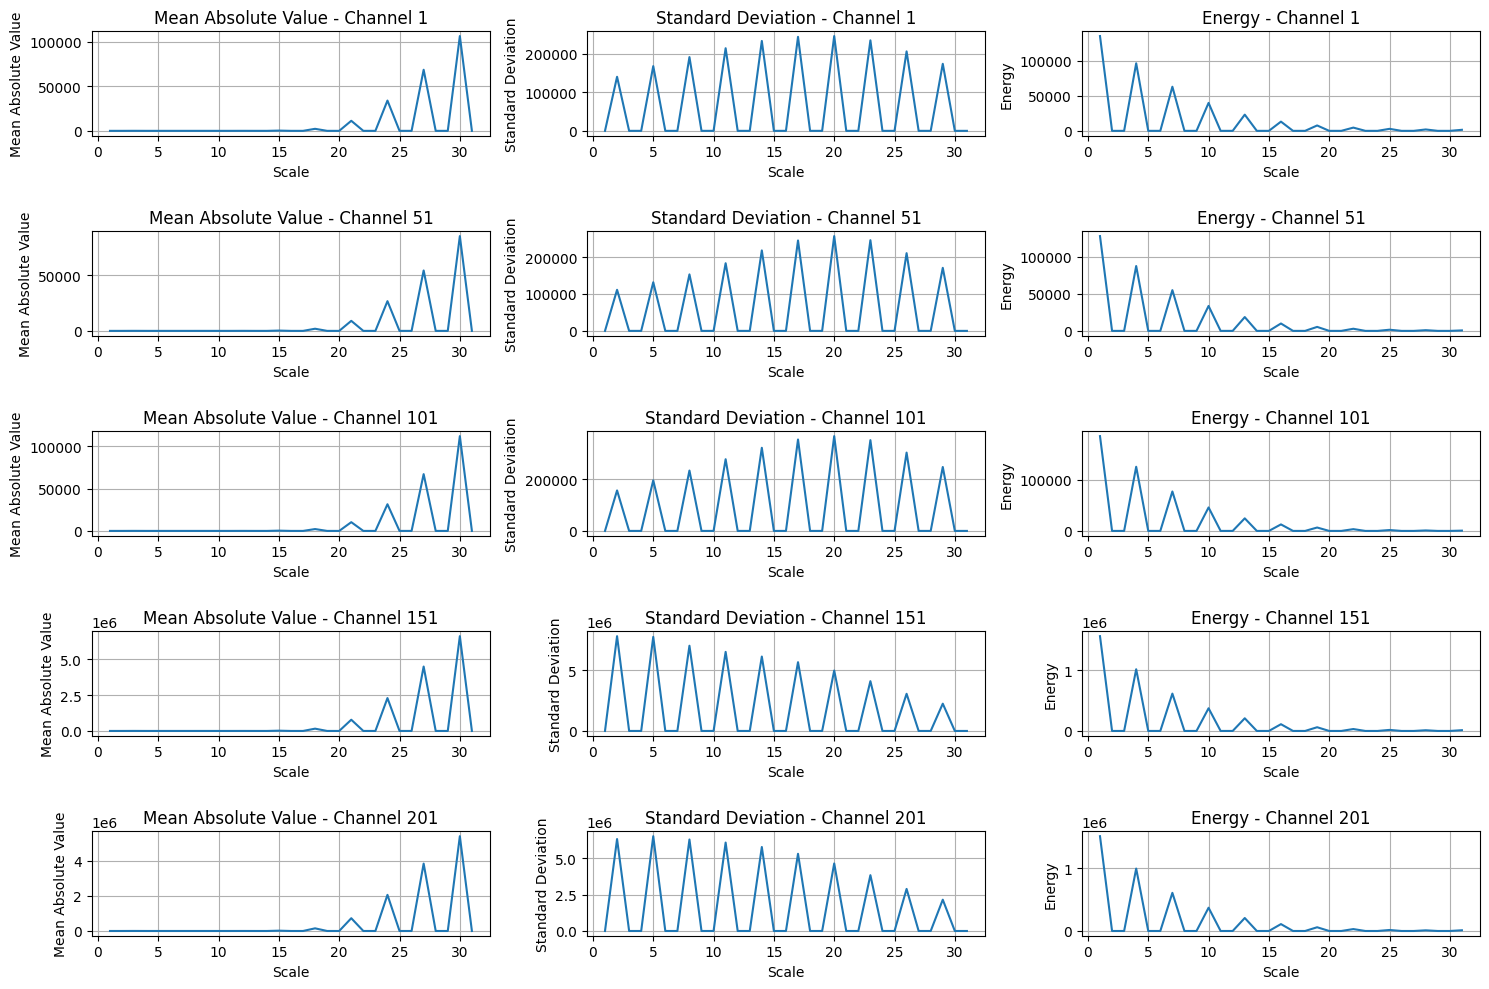

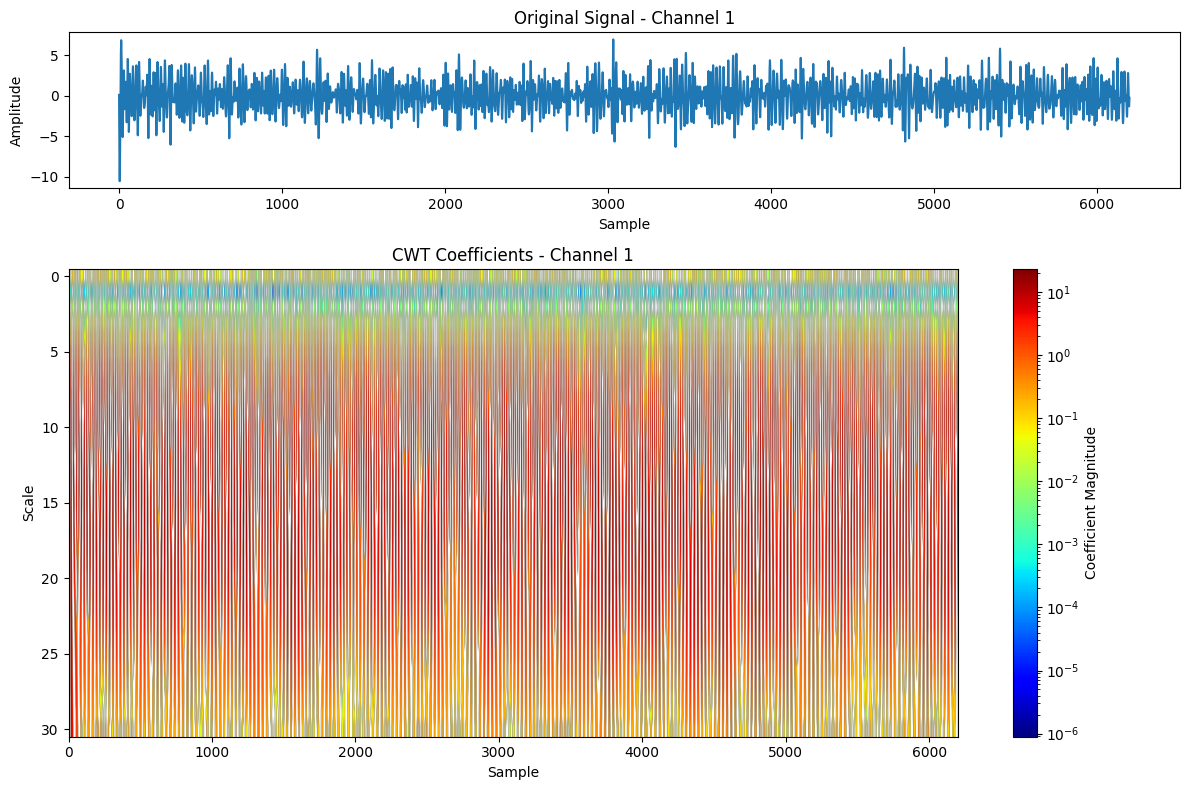

In [7]:
visualize_wpt_features(wpt_features, level=4)
visualize_cwt_features(cwt_features, scales=scales)

channel_to_plot = 0
visualize_cwt_coeffs(hfb_data, channel=channel_to_plot, wavelet='morl', scales=scales)

## Step 7 - Spatial Patterns (CSP/FBCSP)
Common Spatial Pattern (CSP) extracts spatial filters that maximize variance differences between two classes. 
Filter Bank CSP (FBCSP) applies this to multiple frequency bands (here: HFB and LMP) and concatenates the results.

This step demonstrates:
1. Computing CSP filters for HFB and LMP bands.
2. Visualizing spatial patterns (channel weights).
3. Extracting log-variance features for classification.

In [11]:
n_windows = hfb_windows.shape[0]

demo_labels = np.array([0 if i < n_windows // 2 else 1 for i in range(n_windows)])
np.random.seed(42)
demo_labels = np.random.permutation(demo_labels)

print(f'Windows: {n_windows}, Labels distribution: Class 0={np.sum(demo_labels == 0)}, Class 1={np.sum(demo_labels == 1)}')

fbcsp_result = extract_fbcsp_features(hfb_windows, lmp_windows, demo_labels, n_components=4)

print(f'Combined FBCSP features shape: {fbcsp_result["features"].shape}')
print(f'Bands used: {fbcsp_result["band_names"]}')
for band_name, filters in fbcsp_result["filters"].items():
    print(f'  {band_name} filters shape: {filters.shape}')
    visualize_csp_filters(filters, band_name=band_name, step=50)

visualize_csp_features(fbcsp_result["features"], demo_labels, fbcsp_result["band_names"])

Windows: 27, Labels distribution: Class 0=13, Class 1=14


NameError: name 'extract_fbcsp_features' is not defined

## Step 8 - Next Extensions (Optional)
You can now plug these features into a classifier or regressor by:
- using `hfb_windows` / `lmp_windows` as temporal inputs
- concatenating `wpt_features`, `cwt_features`, and `fbcsp_features` as descriptors
- adding labels aligned to the same sample index timeline